# Agents

## Helpers

In [ ]:
import os
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch.nn.functional as F

def _load_model_and_tokenizer(model_id, cache_dir=None):
    """Loads the model and tokenizer."""
    cwd = os.getcwd()
    cache_dir = cwd + "/huggingface/.cache"
    os.makedirs(cache_dir, exist_ok=True)

    print(f"Loading {model_id}...")
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        cache_dir=cache_dir,
        dtype=torch.float16,
        low_cpu_mem_usage=True
    )
    model.eval()
    return model, tokenizer

model_id = "qwen/qwen2.5-0.5B-instruct"
model, tokenizer = _load_model_and_tokenizer(model_id)

In [ ]:
from abc import ABC, abstractmethod
from typing import List

class Agent(ABC):
    @abstractmethod
    def query(self, prompt: str, labels: List[str]) -> List[float]:
        raise NotImplementedError("Subclasses must implement this method")

class HFAgent(Agent):
    SYSTEM_MESSAGE = "You are a helpful assistant. Answer shortly with only your choice with no explanation.\n\n"

    def __init__(self, model, tokenizer):
        self.model = model
        self.tokenizer = tokenizer
        self.system_prompt = self.SYSTEM_MESSAGE
    
    def _convert_to_chat_template(self, text):
        messages = [
            {
                "role": "system",
                "content": self.system_prompt
            },
            {
                "role": "user",
                "content": text
            }
        ]
        return self.tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )

q1_template = "You have two options:\nOption 1 - {A}\nOption 2 - {B}\nWhich do you prefer?\nAnswer: "
options = ['Green', 'Purple']
q1 = q1_template.format(A=options[0], B=options[1])
q1_rev = q1_template.format(A=options[1], B=options[0])

## Lotan v0

In [ ]:
class LotanHFAgentV0(HFAgent):
    def query(self, prompt: str, labels: List[str]) -> List[float]:
        prompt = self._convert_to_chat_template(prompt)
        scores = []
        metadata = {}
        for label in labels:
            full_text = prompt + " " + label
            input_ids = self.tokenizer.encode(full_text, return_tensors="pt").to(self.model.device)
            prompt_ids = self.tokenizer.encode(prompt, return_tensors="pt").to(self.model.device)
            prompt_len = prompt_ids.shape[1]
            with torch.no_grad():
                outputs = self.model(input_ids)
                logits = outputs.logits
            label_logits = logits[0, prompt_len-1 : -1, :] 
            label_ids = input_ids[0, prompt_len:]
            metadata[label] = {
                'input_ids': input_ids,
                'logits': logits,
                'label_ids': label_ids
            }
            loss = F.cross_entropy(label_logits, label_ids, reduction='sum')
            scores.append(-loss.item())
        return scores, metadata

In [ ]:
lotan_v0 = LotanHFAgentV0(model, tokenizer)
lotan_v0_scores, lotan_v0_metadata = lotan_v0.query(q1, labels=['Option 1', 'Option 2'])
lotan_v0_scores

In [ ]:
print(tokenizer.decode(lotan_v0_metadata['Option 1']['input_ids'][0]))

In [ ]:
lotan_v0_metadata['Option 1']

In [ ]:
tokenizer.decode(lotan_v0_metadata['Option 1']['label_ids'])

This space is the problem!

## Itay v0

In [ ]:
class ItayHFAgentV0(HFAgent):
    """ The original model from Itay's paper """
    def get_chat_format_one_side(self, text, role):
        return {
            "role": role,
            "content": text,
        }

    def convert_to_chat_format(self, text, few_shots_texts=None):
        """
        Uses the apply_chat_template function in the tokenizer of the predictor to convert the text to chat format
        """
        SYSTEM_MESSAGE = "You are a helpful assistant. Answer shortly with only your choice with no explanation.\n\n"
        # if there are no few shots, just add the system message to the text
        if few_shots_texts is None:
            messages = [
                self.get_chat_format_one_side(SYSTEM_MESSAGE + text, "user"),
            ]
        # if there are few shots, add the system message to the first shot

        else:
            # the first shot needs the system message before the text
            messages = [
                self.get_chat_format_one_side(
                    SYSTEM_MESSAGE + few_shots_texts[0]["question"], "user"
                ),
                self.get_chat_format_one_side(
                    few_shots_texts[0]["answer"], "assistant"
                ),
            ]

            # after that, add all the other shot in the user and assistent format
            for shot in few_shots_texts[1:]:
                messages.extend(
                    [
                        self.get_chat_format_one_side(shot["question"], "user"),
                        self.get_chat_format_one_side(shot["answer"], "assistant"),
                    ]
                )

            # finaly, add the actual text to the user
            messages.append(self.get_chat_format_one_side(text, "user"))

        prompt = self.tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,  # , return_tensors="pt"
        )

        return prompt
    
    def query(self, prompt, labels):
        prompt = [self.convert_to_chat_format(p) for p in prompt]
        # concat labels to the corrposnded input text
        input_with_answers = [i + label for label in labels for i in prompt]
        # get labels tokens ids
        labels_tokens = self.tokenizer(labels, add_special_tokens=False)["input_ids"]
        # get the last token id of each label
        labels_tokens = [label[-1] for label in labels_tokens]
        # Ensure pad token exists before padding
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token
        # Get encodings for each input text using direct call instead of batch_encode_plus
        input_enc = self.tokenizer(
            input_with_answers,
            return_tensors="pt",
            padding="longest",
        )
        for k, v in input_enc.items():
            input_enc[k] = v.to(self.model.device)

        # Get model output logits
        model_output = self.model(**input_enc)

        # Compute the log probabilities associated with each of the labels
        labels_log_probs = F.log_softmax(model_output.logits, dim=-1)

        # Get the ids of the token before the last token before padding (to see the probablity of the last token given the one before the last token)
        before_padding_ids = (
            input_enc["input_ids"].ne(self.tokenizer.pad_token_id).sum(-1) - 2
        )

        # Collect labels scores from the -2 token in labels_log_probs (the one that predict the last token)
        # and collect for each line the id in labels_tokens
        labels_scores = labels_log_probs[:, before_padding_ids, labels_tokens]

        # Need just the diagonal of the matrix, as it the prob of the label for each line
        labels_scores = torch.diag(labels_scores)

        metadata = {
            'input_ids': input_enc.input_ids,
            'logits': model_output.logits,
        }

        return labels_scores, metadata


In [ ]:
itay_v0 = ItayHFAgentV0(model, tokenizer)
itay_v0_scores, itay_v0_metadata = itay_v0.query([q1], labels=['Option 1','Option 2'])
itay_v0_scores

## Lotan v1

In [ ]:
class LotanHFAgentV1(HFAgent):
    def query(self, prompt: str, labels: List[str]) -> List[float]:
        prompt = self._convert_to_chat_template(prompt)
        scores = []
        metadata = {}
        prompt_ids = self.tokenizer.encode(prompt, return_tensors="pt").to(self.model.device)

        for label in labels:
            label_ids = self.tokenizer.encode(label, return_tensors="pt").to(self.model.device)
            input_ids = torch.cat([prompt_ids, label_ids], dim=1).to(self.model.device)
            prompt_len = prompt_ids.shape[1]
            with torch.no_grad():
                outputs = self.model(input_ids)
                logits = outputs.logits
            label_logits = logits[0, prompt_len-1 : -1, :] 
            label_ids = input_ids[0, prompt_len:]
            metadata[label] = {
                'input_ids': input_ids,
                'logits': logits,
                'label_ids': label_ids
            }
            loss = F.cross_entropy(label_logits, label_ids, reduction='sum')
            scores.append(-loss.item())
        return scores, metadata

In [ ]:
lotan_v1 = LotanHFAgentV1(model, tokenizer)
lotan_v1_scores, lotan_v1_metadata = lotan_v1.query(q1, labels=['Option 1', 'Option 2'])
lotan_v1_scores

In [ ]:
tokenizer.decode(lotan_v1_metadata['Option 1']['label_ids'])

lotan_v1 calculates:
`Score = log P("Option" | prompt) + log P(" 1" | prompt + "Option")`

while itay_v0 calculates:
`Score = log P(" 1" | prompt + "Option")`

This adds a fixed "bias" for lotan_v1 equal `log P("Option" | prompt)`

In [ ]:
tokenizer.decode(lotan_v1_metadata['Option 1']['input_ids'][0])

## Itay v1

In [ ]:
class ItayHFAgentV1(HFAgent):
    """
    - Fixed system prompt issue.
    - Used simpler convert_to_chat_format
    - covnerting prompts in the query function.
    """
    def query(self, prompts, labels):
        if not isinstance(prompts, list):
            prompts = [prompts]
        prompts = [self._convert_to_chat_template(p) for p in prompts]
        # concat labels to the corrposnded input text
        input_with_answers = [i + label for label in labels for i in prompts]
        # get labels tokens ids
        labels_tokens = self.tokenizer(labels, add_special_tokens=False)["input_ids"]
        # get the last token id of each label
        labels_tokens = [label[-1] for label in labels_tokens]
        # Ensure pad token exists before padding
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token
        # Get encodings for each input text using direct call instead of batch_encode_plus
        input_enc = self.tokenizer(
            input_with_answers,
            return_tensors="pt",
            padding="longest",
        )
        for k, v in input_enc.items():
            input_enc[k] = v.to(self.model.device)

        # Get model output logits
        model_output = self.model(**input_enc)

        # Compute the log probabilities associated with each of the labels
        labels_log_probs = F.log_softmax(model_output.logits, dim=-1)

        # Get the ids of the token before the last token before padding (to see the probablity of the last token given the one before the last token)
        before_padding_ids = (
            input_enc["input_ids"].ne(self.tokenizer.pad_token_id).sum(-1) - 2
        )

        # Collect labels scores from the -2 token in labels_log_probs (the one that predict the last token)
        # and collect for each line the id in labels_tokens
        labels_scores = labels_log_probs[:, before_padding_ids, labels_tokens]

        # Need just the diagonal of the matrix, as it the prob of the label for each line
        labels_scores = torch.diag(labels_scores)

        metadata = {
            'input_ids': input_enc.input_ids,
            'logits': model_output.logits,
        }

        return labels_scores, metadata


In [ ]:
itay_v1 = ItayHFAgentV1(model, tokenizer)
itay_v1_scores, itay_v1_metadata = itay_v1.query([q1], labels=['Option 1', 'Option 2'])
itay_v1_scores

In [ ]:
print(tokenizer.decode(itay_v1_metadata['input_ids'][0]))

In [ ]:
q2_template = "Which do you prefer: {A} or {B}?"
q2 = q2_template.format(A=options[0], B=options[1])

In [ ]:
itay_v1_scores_2, itay_v1_metadata_2 = itay_v1.query([q1], labels=options)
itay_v1_scores_2

# Bradley-Terry

In [13]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
from scipy.special import expit  # This is the sigmoid function
from scipy.stats import chi2

from src.pref_models import fit_bradley_terry as fit_bt


def compute_probabilities(df: pd.DataFrame) -> pd.DataFrame:
    """Converts raw logprobs into softmax probabilities."""
    df = df.copy()
    # expit(x) is numerically stable sigmoid
    df['prob_a'] = expit(df['score_a'] - df['score_b'])
    df['prob_b'] = 1 - df['prob_a']
    return df

def aggregate_to_combinations(df: pd.DataFrame) -> pd.DataFrame:
    """Standardizes pairs to (i, j) where i < j, and averages their probabilities."""
    records = []
    for _, row in df.iterrows():
        # Lexicographical sort to ensure consistent (item_i, item_j) ordering
        if row['option_a'] < row['option_b']:
            i, j = row['option_a'], row['option_b']
            p_i = row['prob_a']
        else:
            i, j = row['option_b'], row['option_a']
            p_i = row['prob_b'] # If order was flipped, we track prob of the new 'i'
            
        records.append({'template': row['template'], 'item_i': i, 'item_j': j, 'prob_i_over_j': p_i})
        
    comb_df = pd.DataFrame(records)
    # Average the probabilities for every unique pair combination
    return comb_df.groupby(['template', 'item_i', 'item_j'], as_index=False).mean()

def create_item_mapping(combinations_df: pd.DataFrame) -> dict:
    """Maps unique string items to integer indices 0 to N-1."""
    items = pd.concat([combinations_df['item_i'], combinations_df['item_j']]).unique()
    return {item: idx for idx, item in enumerate(sorted(items))}

def fit_bradley_terry(combinations_df: pd.DataFrame, item_mapping: dict, alpha: float = 1e-4) -> np.ndarray:
    """Fits the Bradley-Terry model using Scipy."""
    n_items = len(item_mapping)
    
    # Map item strings to their array indices
    i_indices = combinations_df['item_i'].map(item_mapping).values
    j_indices = combinations_df['item_j'].map(item_mapping).values
    targets = combinations_df['prob_i_over_j'].values
    
    def objective(r):
        """BCE Loss function to minimize."""
        # Calculate predicted probabilities: sigmoid(r_i - r_j)
        logits = r[i_indices] - r[j_indices]
        preds = expit(logits)
        
        # Binary Cross-Entropy
        eps = 1e-15 # Prevent log(0)
        bce = -targets * np.log(preds + eps) - (1 - targets) * np.log(1 - preds + eps)
        
        # L2 Regularization (Ridge)
        # Because BT scores are translation invariant (r_i - r_j is the same if we add +5 to both),
        # we need a tiny penalty to anchor the scores around 0 so the optimizer doesn't drift.
        l2_penalty = alpha * np.sum(r**2)
        
        return np.sum(bce) + l2_penalty

    # Initialize all latent scores to 0
    initial_r = np.zeros(n_items)
    
    # Run the L-BFGS-B optimizer
    result = minimize(objective, initial_r, method='L-BFGS-B')
    
    if not result.success:
        print(f"Warning: Optimization failed. {result.message}")
        
    return result.x # Returns the array of fitted latent scores        

def create_probability_matrix(scores: np.ndarray, mapping: dict) -> pd.DataFrame:
    index_to_item = {idx: item for item, idx in mapping.items()}
    items = [index_to_item[i] for i in range(len(scores))]
    
    score_diffs = scores[:, np.newaxis] - scores[np.newaxis, :]
    prob_matrix = expit(score_diffs)
    np.fill_diagonal(prob_matrix, 0.5)
    
    return pd.DataFrame(prob_matrix, index=items, columns=items)

def matrix_distance(matrix_p: pd.DataFrame, matrix_q: pd.DataFrame) -> dict:
    # Extract underlying numpy arrays
    P = matrix_p.values
    Q = matrix_q.values
    
    # Get indices for the strict upper triangle (offset=1 ignores the diagonal)
    i, j = np.triu_indices_from(P, k=1)
    
    p_vals = P[i, j]
    q_vals = Q[i, j]
    
    # 1. Mean Absolute Error (MAE)
    mae = np.mean(np.abs(p_vals - q_vals))
    
    # 2. Kullback-Leibler Divergence
    eps = 1e-15 # Prevent log(0)
    p_safe = np.clip(p_vals, eps, 1 - eps)
    q_safe = np.clip(q_vals, eps, 1 - eps)
    
    kl_div = np.mean(
        p_safe * np.log(p_safe / q_safe) + 
        (1 - p_safe) * np.log((1 - p_safe) / (1 - q_safe))
    )
    
    return {'MAE': mae, 'KL_Divergence': kl_div}

def get_predicted_probabilities(latent_scores: np.ndarray, combinations_df: pd.DataFrame, item_mapping: dict) -> np.ndarray:
    """Generates the model's predicted probabilities for the combinations."""
    agg_comb_df = combinations_df[['item_i', 'item_j','prob_i_over_j']].groupby(['item_i', 'item_j'], as_index=False).mean()
    i_indices = agg_comb_df['item_i'].map(item_mapping).values
    j_indices = agg_comb_df['item_j'].map(item_mapping).values
    
    logits = latent_scores[i_indices] - latent_scores[j_indices]
    return expit(logits)

def get_empirical_probabilities(df, col_item1='item_1', col_item2='item_2', col_prob1='prob_1'):
    """
    df: Your raw dataframe
    col_item1: Name of the column containing the first option in the prompt
    col_item2: Name of the column containing the second option in the prompt
    col_prob1: The softmaxed probability (0.0 to 1.0) that the LLM preferred item_1
    """
    df = df.copy()
    
    # 1. Standardize the direction (e.g., alphabetically) so (A,B) and (B,A) map to the same pair
    df['item_1'] = df[[col_item1, col_item2]].min(axis=1)
    df['item_2'] = df[[col_item1, col_item2]].max(axis=1)
    
    # 2. Align the probability to the new standardized 'item_1'
    # If item_1 became item_1, keep prob_1. 
    # If item_1 became item_2 (meaning it was swapped), the probability for item_1 is (1 - prob_1).
    df['p_ij'] = np.where(
        df[col_item1] == df['item_1'], 
        df[col_prob1], 
        1.0 - df[col_prob1]
    )
    
    # 3. Group by the standardized pair and calculate the mean probability & count
    empirical_df = df.groupby(['item_1', 'item_2']).agg(
        p_ij_empirical=('p_ij', 'mean'), # The unified probability you need for the BT model
        n_prompts=('p_ij', 'count')      # How many permutations/prompts were run for this pair
    ).reset_index()
    
    return empirical_df

def calculate_goodness_of_fit(p_emp, p_pred, n, num_items):
    """
    p_emp: Array of empirical probabilities from the LLM
    p_pred: Array of predicted probabilities from your fitted BT model
    n: Array (or scalar) of the number of prompts per pair
    num_items: Total number of unique items in the Bradley-Terry model
    """
    # Degrees of freedom: total pairs - number of fitted parameters
    df = len(p_emp) - (num_items - 1)
    
    # Clip probabilities to avoid division by zero or log(0)
    eps = 1e-10
    p_emp = np.clip(p_emp, eps, 1 - eps)
    p_pred = np.clip(p_pred, eps, 1 - eps)
    
    # 1. Likelihood Ratio Test (Residual Deviance)
    deviance_terms = p_emp * np.log(p_emp / p_pred) + (1 - p_emp) * np.log((1 - p_emp) / (1 - p_pred))
    deviance = 2 * np.sum(n * deviance_terms)
    p_val_deviance = chi2.sf(deviance, df)
    
    # 2. Pearson's Chi-Square Test
    chi2_stat = np.sum(n * ((p_emp - p_pred)**2) / (p_pred * (1 - p_pred)))
    p_val_chi2 = chi2.sf(chi2_stat, df)
    
    return {
        "Deviance": deviance,
        "Deviance_p_value": p_val_deviance,
        "Chi_Square": chi2_stat,
        "Chi_Square_p_value": p_val_chi2,
        "Degrees_of_Freedom": df
    }

In [95]:
def analyze(data_path, verbose=False):
    df = pd.read_csv(data_path)
    if verbose: print(f"Loaded {len(df)} rows from {data_path}")
    
    df_probs = compute_probabilities(df)

    df_combos = aggregate_to_combinations(df_probs)
    mapping = create_item_mapping(df_combos)
    scores_combos = fit_bradley_terry(df_combos, mapping)
    if verbose: print(f"BT scores with combinations: {scores_combos}")
    
    df_probs.rename(columns={'option_a': 'item_i', 'option_b': 'item_j',
                             'score_a': 'score_i', 'score_b': 'score_j',
                             'prob_a': 'prob_i', 'prob_b': 'prob_j'},
                    inplace=True)
    df_probs['prob_i_over_j'] = df_probs['prob_i'] / (df_probs['prob_i'] + df_probs['prob_j'])
    scores_probs = fit_bradley_terry(df_probs, mapping)
    if verbose: print(f"BT scores with probabilities: {scores_probs}")
    
    df['winner'] = df_probs.apply(lambda row: row['item_i'] if row['prob_i'] > row['prob_j'] else row['item_j'], axis=1)
    df.rename(columns={'option_a': 'item_a', 'option_b': 'item_b'}, inplace=True)
    ranking, _ = fit_bt(df, mapping.keys())
    ranking = ranking.sort_index(key=lambda x: x.map(mapping))
    if verbose: print(f"BT scores with winners: {ranking['BT_Score'].values}")
    
    df_p_combos = create_probability_matrix(scores_combos, mapping)
    df_p_probs = create_probability_matrix(scores_probs, mapping)
    df_p_winners = create_probability_matrix(ranking['BT_Score'].values, mapping)
    combos_probs_distance = matrix_distance(df_p_combos, df_p_probs)
    if verbose: print(f"Distance between Combos and Probs: MAE: {combos_probs_distance['MAE']:.4f}, KL Divergence: {combos_probs_distance['KL_Divergence']:.4f}")
    combos_winners_distance = matrix_distance(df_p_combos, df_p_winners)
    if verbose: print(f"Distance between Combos and Winners: MAE: {combos_winners_distance['MAE']:.4f}, KL Divergence: {combos_winners_distance['KL_Divergence']:.4f}")
    
    rankings_combos = ' > '.join([name for name, _ in sorted(zip(mapping, scores_combos), key=lambda x: x[1], reverse=True)])
    rankings_probs = ' > '.join([name for name, _ in sorted(zip(mapping, scores_probs), key=lambda x: x[1], reverse=True)])
    rankings_winners = ' > '.join([name for name, _ in sorted(zip(mapping, ranking['BT_Score'].values), key=lambda x: x[1], reverse=True)])
    
    if verbose: print("Combos: ", rankings_combos)
    if verbose: print("Probs: ", rankings_probs)
    if verbose: print("Winners: ", rankings_winners)
    
    df_gof = get_empirical_probabilities(df_probs, col_item1='item_i', col_item2='item_j', col_prob1='prob_i_over_j')
    df_gof['p_pred'] = get_predicted_probabilities(scores_combos, df_combos, mapping)
    gof = calculate_goodness_of_fit(df_gof.p_ij_empirical.values, df_gof.p_pred.values, df_gof.n_prompts.values, len(mapping))
    alpha = 0.05
    gof['Good_Fit_Deviance'] = gof['Deviance_p_value'] > alpha
    gof['Good_Fit_Chi'] = gof['Chi_Square_p_value'] > alpha
    if verbose:
        print(f"Goodness of Fit:")
        for key, value in gof.items():
            print(f"- {key}: {value}")
    
    return {
        'scores_combos': scores_combos,
        'scores_probs': scores_probs,
        'scores_winners': ranking['BT_Score'].values,
        'mapping': mapping,
        'df_combos': df_combos,
        'df_probs': df_probs,
        'df_winners': df,
        'rankings_combos': rankings_combos,
        'rankings_probs': rankings_probs,
        'rankings_winners': rankings_winners,
        **gof
    }

In [87]:
results = analyze('data/new_prompts/qwen-32-laptop_brands-20260512_165541/scores.csv')

Loaded 860 rows from data/new_prompts/qwen-32-laptop_brands-20260512_165541/scores.csv
BT scores with combinations: [ 1.49321902  3.04379624 -1.60032751 -1.52592221 -1.41076562]
BT scores with probabilities: [ 1.49324777  3.04385459 -1.6003567  -1.52595076 -1.41079356]
BT scores with winners: [ 1.47344539  3.21350365 -1.63009214 -1.55739748 -1.49945942]
Distance between Combos and Probs: MAE: 0.0000, KL Divergence: 0.0000
Distance between Combos and Winners: MAE: 0.0065, KL Divergence: 0.0004
Combos:  Apple > ASUS > Lenovo > HP > Dell
Probs:  Apple > ASUS > Lenovo > HP > Dell
Winners:  Apple > ASUS > Lenovo > HP > Dell
Goodness of Fit:
- Deviance: 14.556057744638611
- Deviance_p_value: 0.024005346740896934
- Chi_Square: 19.377023432011523
- Chi_Square_p_value: 0.003572088559075576
- Degrees_of_Freedom: 6
- Good_Fit_Deviance: False
- Good_Fit_Chi: False


### Print all GoF

In [ ]:
import os

records = []
base = 'data/new_prompts'
for exp_dir in os.listdir(base):
    if exp_dir.startswith('qwen-'):
        print(f"Analyzing {exp_dir}...")
        model_size, alternative_set = exp_dir.split('-')[1:3]
        results = analyze(os.path.join(base, exp_dir, 'scores.csv'))
        records.append({
            'model_size': model_size,
            'alternative_set': alternative_set,
            'combos_rankings': results['rankings_combos'],
            'rankings_same': results['rankings_probs'] == results['rankings_combos'] == results['rankings_winners'],
            'Good_Fit_Deviance': results['Good_Fit_Deviance'],
            'Good_Fit_Chi': results['Good_Fit_Chi'],
            "p_val_deviance": results['Deviance_p_value'],
            "p_val_chi2": results['Chi_Square_p_value'],
            'prob_i_avg': results['df_probs']['prob_i'].mean(),
            'prob_j_avg': results['df_probs']['prob_j'].mean(),
            'prob_i_med': results['df_probs']['prob_i'].median(),
            'prob_j_med': results['df_probs']['prob_j'].median(),
        })
df = pd.DataFrame(records)
df

Analyzing qwen-72-colors-20260512_164043...
Loaded 860 rows from data/new_prompts/qwen-72-colors-20260512_164043/scores.csv
BT scores with combinations: [ 1.1503566   0.52488748 -0.69423694 -0.31337668 -0.66763082]
BT scores with probabilities: [ 1.15067906  0.52500815 -0.69441848 -0.31346331 -0.66780521]
BT scores with winners: [ 1.34760911  0.49313912 -0.76167076 -0.30584206 -0.77323541]
Distance between Combos and Probs: MAE: 0.0000, KL Divergence: 0.0000
Distance between Combos and Winners: MAE: 0.0220, KL Divergence: 0.0021
Combos:  blue > green > red > yellow > purple
Probs:  blue > green > red > yellow > purple
Winners:  blue > green > red > purple > yellow
Goodness of Fit:
- Deviance: 59.626879541736855
- Deviance_p_value: 5.3591406758720654e-11
- Chi_Square: 64.47222491938219
- Chi_Square_p_value: 5.528631729613164e-12
- Degrees_of_Freedom: 6
- Good_Fit_Deviance: False
- Good_Fit_Chi: False
Analyzing qwen-0.5-foods-20260512_163106...
Loaded 1806 rows from data/new_prompts/qwen

,model_size,alternative_set,combos_rankings,rankings_same,Good_Fit_Deviance,Good_Fit_Chi,p_val_deviance,p_val_chi2,prob_i_avg,prob_j_avg,prob_i_med,prob_j_med
0,72,colors,blue > green > red > yellow > purple,False,False,False,5.359141e-11,5.528632e-12,0.714024,0.285976,0.923039,0.076961
1,0.5,foods,Tacos > Sushi > Pasta > Salad > Pizza > Burger...,False,True,True,1.000000e+00,1.000000e+00,0.520817,0.479183,0.503906,0.496094
2,32,laptops,"Lenovo ThinkPad X1 Carbon (Ryzen 7, 32GB, $140...",True,False,False,1.489959e-205,4.273071e-162,0.772658,0.227342,0.999934,0.000066
3,7,stocks,Tesla > Nvidia > Apple > Google > Microsoft > ...,True,False,False,4.014682e-05,2.663201e-05,0.811915,0.188085,0.985734,0.014266
4,7,laptops,"Lenovo ThinkPad E14 (Ryzen 5, 16GB, $800) > Le...",True,False,False,1.426672e-71,9.213464e-59,0.876395,0.123605,0.999864,0.000136
5,72,cars,Tesla > Mercedes > Toyota > BMW > Audi > Honda...,True,False,True,4.032897e-02,6.259877e-02,0.747215,0.252785,0.995734,0.004266
6,72,stocks,Microsoft > Google > Nvidia > Apple > Tesla > ...,True,False,False,2.436163e-11,3.599350e-11,0.722381,0.277619,0.993865,0.006135
7,32,stocks,Nvidia > Tesla > Google > Amazon > Meta > Micr...,True,False,False,9.293597e-11,8.702671e-11,0.724101,0.275899,0.996677,0.003323
8,0.5,cars,Tesla > Toyota > Mercedes > Audi > Ford > Hond...,False,True,True,1.000000e+00,1.000000e+00,0.527266,0.472734,0.507812,0.492188
9,7,laptop_brands,ASUS > Apple > HP > Lenovo > Dell,True,False,False,1.202227e-02,1.262956e-02,0.864846,0.135154,0.961528,0.038472


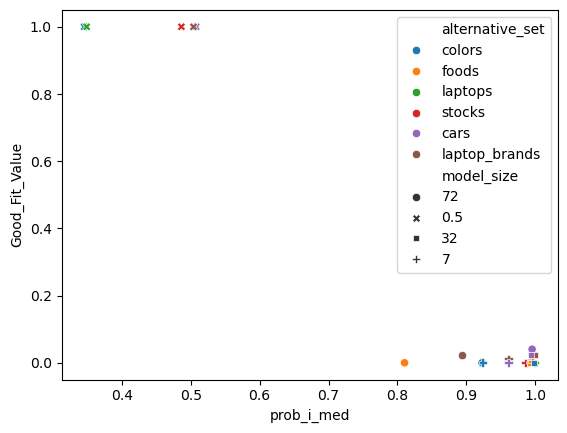

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

df_melted = df.melt(id_vars=['prob_i_med', 'alternative_set', 'model_size'], 
                    value_vars=['p_val_deviance'],
                    var_name='Metric', value_name='Good_Fit_Value')

sns.scatterplot(data=df_melted, 
                x='prob_i_med', 
                y='Good_Fit_Value', 
                hue='alternative_set', 
                style='model_size')
plt.show()

In [ ]:
import os

records = []
for exp_dir in os.listdir('data/prev_prompts'):
    if exp_dir.startswith('qwen-'):
        print(f"Analyzing {exp_dir}...")
        model_size, alternative_set = exp_dir.split('-')[1:3]
        results = analyze(f'data/prev_prompts/{exp_dir}/scores.csv')
        records.append({
            'model_size': model_size,
            'alternative_set': alternative_set,
            'combos_rankings': results['rankings_combos'],
            'rankings_same': results['rankings_probs'] == results['rankings_combos'] == results['rankings_winners'],
            'Good_Fit_Deviance': results['Good_Fit_Deviance'],
            'Good_Fit_Chi': results['Good_Fit_Chi'],
            "p_val_deviance": results['Deviance_p_value'],
            "p_val_chi2": results['Chi_Square_p_value'],
            "p_val_chi2": results['Chi_Square_p_value'],
            'prob_i_avg': results['df_probs']['prob_i'].mean(),
            'prob_j_avg': results['df_probs']['prob_j'].mean(),
            'prob_i_med': results['df_probs']['prob_i'].median(),
            'prob_j_med': results['df_probs']['prob_j'].median(),
            
        })
df_prev = pd.DataFrame(records)
df_prev

Analyzing qwen-0.5-cars-20260512_193327...
Loaded 2184 rows from data/prev_prompts/qwen-0.5-cars-20260512_193327/scores.csv
BT scores with combinations: [ 1.02707748 -1.10071049 -0.98256183 -0.58768585  1.3227745   0.70570331
 -0.38459541]
BT scores with probabilities: [ 1.02732263 -1.10097602 -0.98279697 -0.58782556  1.32310414  0.70586056
 -0.3846915 ]
BT scores with winners: [14.14774444 -7.25689242 -7.22544981 -6.45417372 16.28246637 -3.41668613
 -6.07700873]
Distance between Combos and Probs: MAE: 0.0000, KL Divergence: 0.0000
Distance between Combos and Winners: MAE: 0.1507, KL Divergence: 1.6013
Combos:  Mercedes > Audi > Tesla > Toyota > Honda > Ford > BMW
Probs:  Mercedes > Audi > Tesla > Toyota > Honda > Ford > BMW
Winners:  Mercedes > Audi > Tesla > Toyota > Honda > Ford > BMW
Goodness of Fit:
- Deviance: 45.17150130585565
- Deviance_p_value: 7.194368557688565e-05
- Chi_Square: 43.83102574100791
- Chi_Square_p_value: 0.0001168650283945571
- Degrees_of_Freedom: 15
- Good_Fit_

,model_size,alternative_set,combos_rankings,rankings_same,Good_Fit_Deviance,Good_Fit_Chi,p_val_deviance,p_val_chi2,prob_i_avg,prob_j_avg,prob_i_med,prob_j_med
0,0.5,cars,Mercedes > Audi > Tesla > Toyota > Honda > For...,True,False,False,7.194369e-05,1.168650e-04,0.574058,0.425942,0.590719,0.409281
1,7,foods,Tacos > Pasta > Burger > Sushi > Steak > Salad...,False,True,True,9.960184e-01,9.954581e-01,0.562660,0.437340,0.500000,0.500000
2,32,foods,Tacos > Sushi > Burger > Steak > Pasta > Salad...,False,True,True,7.904882e-01,7.917328e-01,0.535350,0.464650,0.500000,0.500000
3,72,cars,Tesla > Mercedes > Audi > Toyota > BMW > Honda...,False,False,False,6.306379e-18,2.800187e-14,0.558441,0.441559,0.500002,0.499998
4,72,colors,blue > purple > green > red > yellow,True,False,False,3.523946e-07,2.971434e-07,0.769204,0.230796,0.979638,0.020362
5,0.5,laptop_brands,ASUS > Lenovo > Dell > Apple > HP,False,False,False,1.923261e-02,2.028653e-02,0.505424,0.494576,0.500113,0.499887
6,0.5,colors,purple > yellow > blue > green > red,False,True,True,5.427334e-01,5.484040e-01,0.652837,0.347163,0.764889,0.235111
7,0.5,laptops,"HP Pavilion 15 (Ryzen 5, 8GB, $600) > Apple Ma...",False,True,True,1.000000e+00,1.000000e+00,0.529312,0.470688,0.525601,0.474399
8,0.5,foods,Steak > Pasta > Sushi > Tacos > Salad > Burger...,False,True,True,2.217530e-01,2.806520e-01,0.508749,0.491251,0.499879,0.500121
9,7,laptops,"ASUS VivoBook 15 (i3, 8GB, $450) > Lenovo Idea...",False,True,True,1.000000e+00,1.000000e+00,0.500000,0.500000,0.500000,0.500000


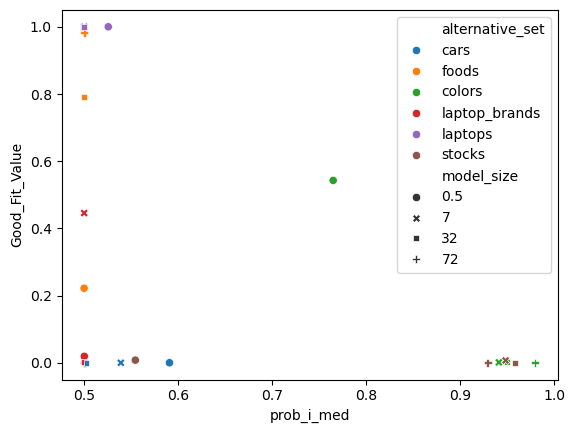

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

df_melted = df_prev.melt(id_vars=['prob_i_med', 'alternative_set', 'model_size'], 
                    value_vars=['p_val_deviance'],
                    var_name='Metric', value_name='Good_Fit_Value')

sns.scatterplot(data=df_melted, 
                x='prob_i_med', 
                y='Good_Fit_Value', 
                hue='alternative_set', 
                style='model_size')
plt.show()

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

def plot_gof_heatmaps(df,
                      x_col='model_size',
                      y_col='alternative_set',
                      dev_col='gof_dev',
                      chi_col='gof_chi'):
    """
    Plots two heatmaps for Goodness of Fit (Deviance and Chi-Square) based on experimental results.
    
    Args:
        df (pd.DataFrame): The dataframe containing the results.
        x_col (str): Column name for the x-axis.
        y_col (str): Column name for the y-axis.
        dev_col (str): Column name for the Deviance GOF boolean.
        chi_col (str): Column name for the Chi-Square GOF boolean.
    """
    pivot_dev = df.pivot_table(index=y_col, columns=x_col, values=dev_col, aggfunc='first').astype(float)
    pivot_chi = df.pivot_table(index=y_col, columns=x_col, values=chi_col, aggfunc='first').astype(float)
    cmap = ListedColormap(['red', 'green'])
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    sns.heatmap(pivot_dev, ax=axes[0], cmap=cmap, cbar=False, linewidths=0.5, linecolor='white')
    axes[0].set_title('GOF: Deviance')
    axes[0].set_xlabel(x_col.replace('_', ' ').title())
    axes[0].set_ylabel(y_col.replace('_', ' ').title())

    sns.heatmap(pivot_chi, ax=axes[1], cmap=cmap, cbar=False, linewidths=0.5, linecolor='white')
    axes[1].set_title('GOF: Chi-Square')
    axes[1].set_xlabel(x_col.replace('_', ' ').title())
    axes[1].set_ylabel('')

    plt.tight_layout()
    plt.show()

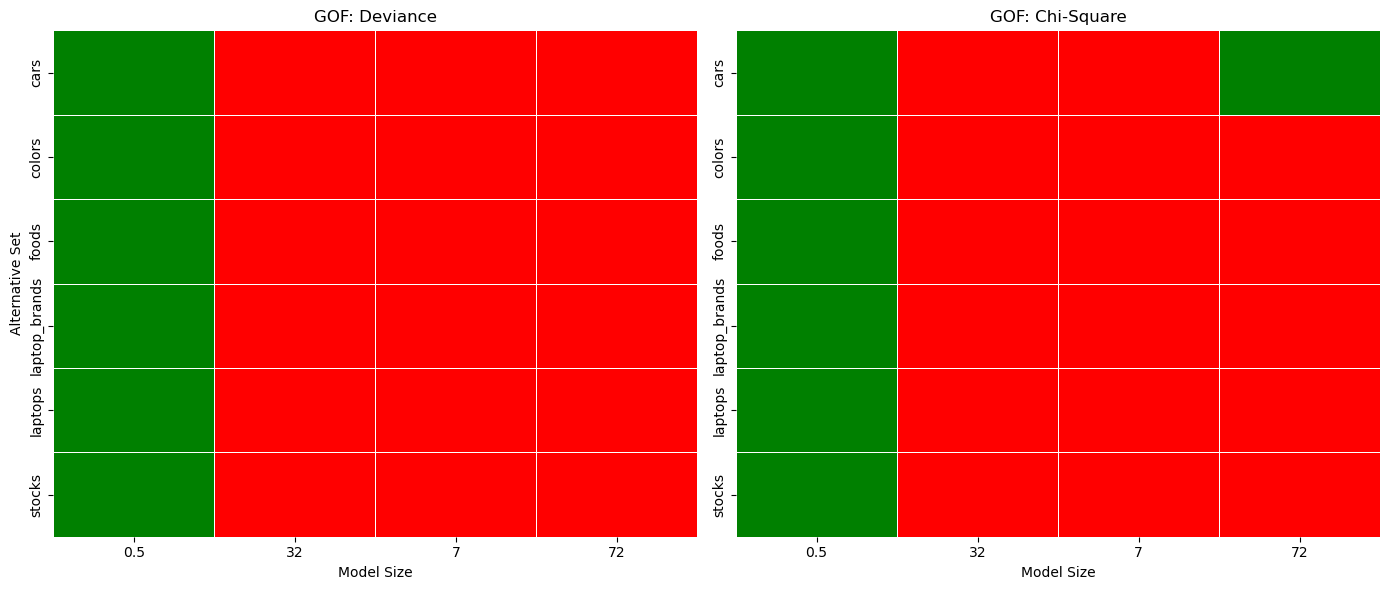

In [30]:
plot_gof_heatmaps(df, x_col='model_size', y_col='alternative_set', dev_col='Good_Fit_Deviance', chi_col='Good_Fit_Chi')

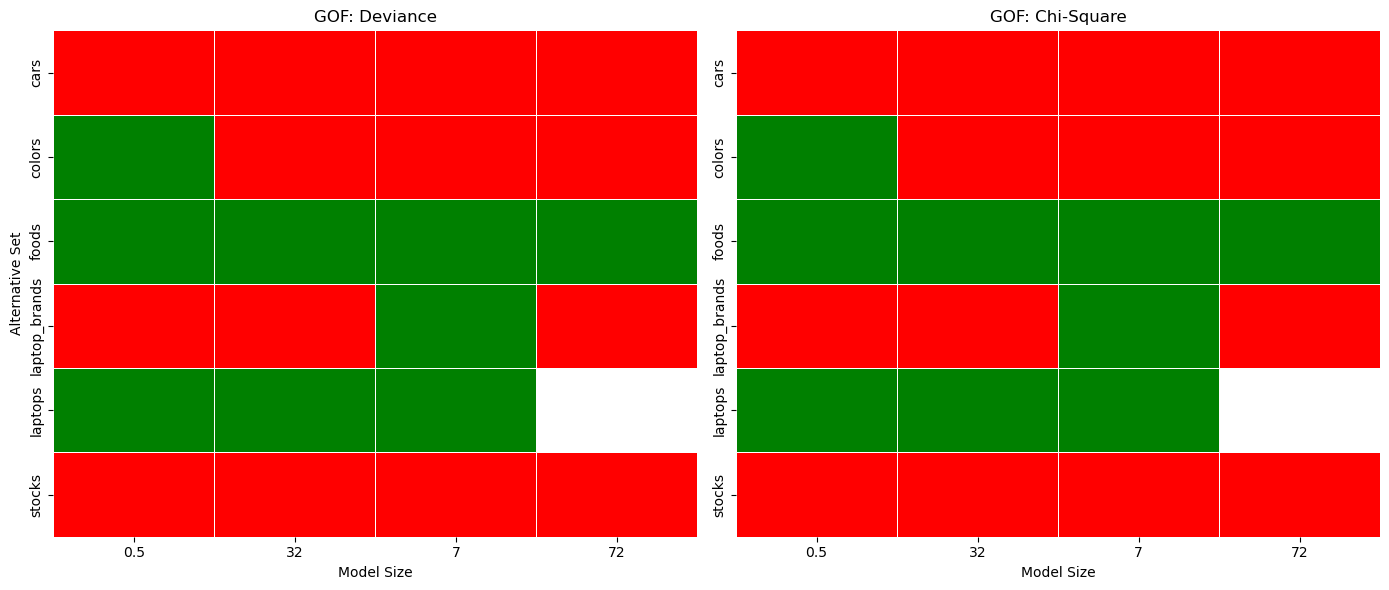

In [31]:
plot_gof_heatmaps(df_prev, x_col='model_size', y_col='alternative_set', dev_col='Good_Fit_Deviance', chi_col='Good_Fit_Chi')

In [28]:
import pandas as pd

def compare_gof_pvals(df1, df2, pval_dev_col='dev_pval', pval_chi_col='chi_pval'):
    """
    Joins two experimental dataframes and calculates the absolute difference 
    between their Goodness of Fit p-values.
    """
    # 1. Merge the dataframes on the primary keys
    # suffixes append to overlapping column names to show their origin
    merged_df = pd.merge(
        df1, 
        df2, 
        on=['model_size', 'alternative_set'], 
        suffixes=('_exp1', '_exp2')
    )
    
    # 2. Calculate the difference
    # Using .abs() to get the magnitude of the difference. 
    # Remove .abs() if you want directional differences (positive/negative).
    merged_df['dev_pval_diff'] = (
        merged_df[f'{pval_dev_col}_exp1'] - merged_df[f'{pval_dev_col}_exp2']
    ).abs()
    
    merged_df['chi_pval_diff'] = (
        merged_df[f'{pval_chi_col}_exp1'] - merged_df[f'{pval_chi_col}_exp2']
    ).abs()
    
    # 3. Filter down to just the keys and the comparison columns for a clean view
    result_cols = [
        'model_size', 'alternative_set', 
        f'{pval_dev_col}_exp1', f'{pval_dev_col}_exp2', 'dev_pval_diff',
        f'{pval_chi_col}_exp1', f'{pval_chi_col}_exp2', 'chi_pval_diff'
    ]
    
    return merged_df[result_cols]

compare_gof_pvals(df, df_prev, pval_dev_col='p_val_deviance', pval_chi_col='p_val_chi2')

,model_size,alternative_set,p_val_deviance_exp1,p_val_deviance_exp2,dev_pval_diff,p_val_chi2_exp1,p_val_chi2_exp2,chi_pval_diff
0,72,colors,5.359141e-11,3.523946e-07,3.523410e-07,5.528632e-12,2.971434e-07,2.971379e-07
1,0.5,foods,1.000000e+00,2.217530e-01,7.782470e-01,1.000000e+00,2.806520e-01,7.193480e-01
2,32,laptops,1.489959e-205,1.000000e+00,1.000000e+00,4.273071e-162,1.000000e+00,1.000000e+00
3,7,stocks,4.014682e-05,6.923784e-03,6.883637e-03,2.663201e-05,7.390785e-03,7.364153e-03
4,7,laptops,1.426672e-71,1.000000e+00,1.000000e+00,9.213464e-59,1.000000e+00,1.000000e+00
5,72,cars,4.032897e-02,6.306379e-18,4.032897e-02,6.259877e-02,2.800187e-14,6.259877e-02
6,72,stocks,2.436163e-11,4.945759e-16,2.436114e-11,3.599350e-11,1.778277e-15,3.599173e-11
7,32,stocks,9.293597e-11,9.947484e-06,9.947391e-06,8.702671e-11,1.118195e-07,1.117325e-07
8,0.5,cars,1.000000e+00,7.194369e-05,9.999281e-01,1.000000e+00,1.168650e-04,9.998831e-01
9,7,laptop_brands,1.202227e-02,4.456808e-01,4.336585e-01,1.262956e-02,4.499087e-01,4.372792e-01


### Second attempt - test by simulating over the data

In [76]:
import itertools
import pandas as pd
import numpy as np
from scipy.stats import chisquare

def assign_proportional_winner(df, item_i_col='item_i', item_j_col='item_j', prob_col='prob_i_over_j'):
    df_sim = df.copy()
    
    # Generate an array of random floats between 0.0 and 1.0
    random_rolls = np.random.rand(len(df_sim))
    
    # If the random roll is less than the probability of i, item_i wins. Otherwise, item_j wins.
    df_sim['winner'] = np.where(
        random_rolls < df_sim[prob_col], 
        df_sim[item_i_col], 
        df_sim[item_j_col]
    )
    
    return df_sim

def simulate_chi_square_tests(results, n_trials=1000, alpha=0.05):
    df_combos = results['df_combos']
    bt_scores = results['scores_combos']
    mapping = results['mapping']
    n_templates = df_combos.template.nunique()
    denom = len(mapping) * (len(mapping) - 1) // 2
    stats = []
    for _ in range(n_trials):
        df_sim = assign_proportional_winner(df_combos)
        records = []
        for item_1, item_2 in itertools.combinations(mapping.keys(), 2):
            bt_i_over_j = expit(bt_scores[mapping[item_1]] - bt_scores[mapping[item_2]])
            obs_i_over_j = len(df_sim[(df_sim['item_i'] == item_1) & (df_sim['item_j'] == item_2) & (df_sim['winner'] == item_1)])
            records.append({
                'item_i': item_1,
                'item_j': item_2,
                'BT_i_over_j': bt_i_over_j,
                'obs_i_over_j': obs_i_over_j,
            })
            records.append({
                'item_i': item_2,
                'item_j': item_1,
                'BT_i_over_j': 1 - bt_i_over_j,
                'obs_i_over_j': n_templates - obs_i_over_j,
            })
        records_df = pd.DataFrame(records)
        records_df['exp_i_over_j'] = n_templates * records_df['BT_i_over_j']
        
        f_obs = records_df['obs_i_over_j'].values / denom
        f_exp = records_df['exp_i_over_j'].values / denom
        statistic, p_value = chisquare(f_obs, f_exp)
        stats.append({
            'statistic': statistic,
            'p_value': p_value
        })

    stats_df = pd.DataFrame(stats)
    good_fit_pct = (stats_df['p_value'] > alpha).mean()
    return good_fit_pct

In [77]:
import os
from tqdm.auto import tqdm

records = []
base = 'data/new_prompts'
for exp_dir in tqdm(os.listdir(base)):
    if exp_dir.startswith('qwen-'):
        model_size, alternative_set = exp_dir.split('-')[1:3]
        results = analyze(os.path.join(base, exp_dir, 'scores.csv'))
        good_fit_pct = simulate_chi_square_tests(results, n_trials=1000, alpha=0.05)
        records.append({
            'model_size': model_size,
            'alternative_set': alternative_set,
            'good_fit_pct': good_fit_pct
        })
        
df = pd.DataFrame(records)
df

  0%|          | 0/24 [00:00<?, ?it/s]

Loaded 860 rows from data/new_prompts/qwen-72-colors-20260512_164043/scores.csv
BT scores with combinations: [ 1.15067557  0.52500699 -0.69441611 -0.31346206 -0.66780285]
BT scores with probabilities: [ 1.15067906  0.52500815 -0.69441848 -0.31346331 -0.66780521]
BT scores with winners: [ 1.34760911  0.49313912 -0.76167076 -0.30584206 -0.77323541]
Distance between Combos and Probs: MAE: 0.0000, KL Divergence: 0.0000
Distance between Combos and Winners: MAE: 0.0220, KL Divergence: 0.0021
Combos:  blue > green > red > yellow > purple
Probs:  blue > green > red > yellow > purple
Winners:  blue > green > red > purple > yellow
Goodness of Fit:
- Deviance: 59.626867291694005
- Deviance_p_value: 5.359171372498641e-11
- Chi_Square: 64.48711657936097
- Chi_Square_p_value: 5.4900761682200656e-12
- Degrees_of_Freedom: 6
- Good_Fit_Deviance: False
- Good_Fit_Chi: False


  4%|▍         | 1/24 [00:07<02:53,  7.54s/it]

Loaded 1806 rows from data/new_prompts/qwen-0.5-foods-20260512_163106/scores.csv
BT scores with combinations: [-0.15254316  0.05103038 -0.03038869  0.04170998 -0.19955813  0.07597191
  0.21377831]
BT scores with probabilities: [-0.15254351  0.05103014 -0.03038888  0.04170972 -0.19955887  0.07597185
  0.21377843]
BT scores with winners: [-0.6195866   0.09703573 -0.15809171  0.17533593 -0.72025639  0.30451914
  0.9210439 ]
Distance between Combos and Probs: MAE: 0.0000, KL Divergence: 0.0000
Distance between Combos and Winners: MAE: 0.1145, KL Divergence: 0.0410
Combos:  Tacos > Sushi > Pasta > Salad > Pizza > Burger > Steak
Probs:  Tacos > Sushi > Pasta > Salad > Pizza > Burger > Steak
Winners:  Tacos > Sushi > Salad > Pasta > Pizza > Burger > Steak
Goodness of Fit:
- Deviance: 0.2598660356130288
- Deviance_p_value: 0.9999999999856797
- Chi_Square: 0.2599142381420673
- Chi_Square_p_value: 0.99999999998566
- Degrees_of_Freedom: 15
- Good_Fit_Deviance: True
- Good_Fit_Chi: True


  8%|▊         | 2/24 [00:21<04:12, 11.46s/it]

...

Loaded 860 rows from data/new_prompts/qwen-32-colors-20260512_163708/scores.csv
BT scores with combinations: [ 0.38979203  0.56205072  1.02176435 -0.14561802 -1.82799013]
BT scores with probabilities: [ 0.38979446  0.56205371  1.02176883 -0.14561759 -1.82800024]
BT scores with winners: [ 0.39021036  0.57009408  1.06423672 -0.11687346 -1.90766771]
Distance between Combos and Probs: MAE: 0.0000, KL Divergence: 0.0000
Distance between Combos and Winners: MAE: 0.0066, KL Divergence: 0.0002
Combos:  purple > green > blue > red > yellow
Probs:  purple > green > blue > red > yellow
Winners:  purple > green > blue > red > yellow
Goodness of Fit:
- Deviance: 60.98355895080696
- Deviance_p_value: 2.8404721295914728e-11
- Chi_Square: 51.95285078115423
- Chi_Square_p_value: 1.905974002012319e-09
- Degrees_of_Freedom: 6
- Good_Fit_Deviance: False
- Good_Fit_Chi: False


 96%|█████████▌| 23/24 [06:40<00:11, 11.87s/it]

Loaded 860 rows from data/new_prompts/qwen-0.5-laptop_brands-20260512_163313/scores.csv
BT scores with combinations: [ 0.09704909  0.20712273 -0.09439377 -0.13514704 -0.07463015]
BT scores with probabilities: [ 0.09704927  0.20712312 -0.09439405 -0.13514752 -0.07463019]
BT scores with winners: [ 0.25031391  0.7482002  -0.33873047 -0.45952846 -0.20025519]
Distance between Combos and Probs: MAE: 0.0000, KL Divergence: 0.0000
Distance between Combos and Winners: MAE: 0.0978, KL Divergence: 0.0289
Combos:  Apple > ASUS > Lenovo > Dell > HP
Probs:  Apple > ASUS > Lenovo > Dell > HP
Winners:  Apple > ASUS > Lenovo > Dell > HP
Goodness of Fit:
- Deviance: 0.20337528729418192
- Deviance_p_value: 0.9998375887189693
- Chi_Square: 0.20293505629542602
- Chi_Square_p_value: 0.9998386146117041
- Degrees_of_Freedom: 6
- Good_Fit_Deviance: True
- Good_Fit_Chi: True


100%|██████████| 24/24 [06:48<00:00, 17.04s/it]


,model_size,alternative_set,good_fit_pct
0,72,colors,1.0
1,0.5,foods,1.0
2,32,laptops,1.0
3,7,stocks,1.0
4,7,laptops,1.0
5,72,cars,1.0
6,72,stocks,1.0
7,32,stocks,1.0
8,0.5,cars,1.0
9,7,laptop_brands,1.0


In [78]:
import os
from tqdm.auto import tqdm

records = []
base = 'data/prev_prompts'
for exp_dir in tqdm(os.listdir(base)):
    if exp_dir.startswith('qwen-'):
        model_size, alternative_set = exp_dir.split('-')[1:3]
        results = analyze(os.path.join(base, exp_dir, 'scores.csv'))
        good_fit_pct = simulate_chi_square_tests(results, n_trials=1000, alpha=0.05)
        records.append({
            'model_size': model_size,
            'alternative_set': alternative_set,
            'good_fit_pct': good_fit_pct
        })
        
df_prev = pd.DataFrame(records)
df_prev

  0%|          | 0/23 [00:00<?, ?it/s]

Loaded 2184 rows from data/prev_prompts/qwen-0.5-cars-20260512_193327/scores.csv
BT scores with combinations: [ 1.02732154 -1.10097224 -0.98279358 -0.58782308  1.32310158  0.70586015
 -0.38468948]
BT scores with probabilities: [ 1.02732263 -1.10097602 -0.98279697 -0.58782556  1.32310414  0.70586056
 -0.3846915 ]
BT scores with winners: [14.14774444 -7.25689242 -7.22544981 -6.45417372 16.28246637 -3.41668613
 -6.07700873]
Distance between Combos and Probs: MAE: 0.0000, KL Divergence: 0.0000
Distance between Combos and Winners: MAE: 0.1507, KL Divergence: 1.6009
Combos:  Mercedes > Audi > Tesla > Toyota > Honda > Ford > BMW
Probs:  Mercedes > Audi > Tesla > Toyota > Honda > Ford > BMW
Winners:  Mercedes > Audi > Tesla > Toyota > Honda > Ford > BMW
Goodness of Fit:
- Deviance: 45.17147105812244
- Deviance_p_value: 7.194447733026576e-05
- Chi_Square: 43.838622605286
- Chi_Square_p_value: 0.0001165458813448464
- Degrees_of_Freedom: 15
- Good_Fit_Deviance: False
- Good_Fit_Chi: False


  4%|▍         | 1/23 [00:15<05:37, 15.33s/it]

Loaded 2184 rows from data/prev_prompts/qwen-7-foods-20260512_193324/scores.csv
BT scores with combinations: [ 0.15072513  0.15358116 -0.86448406  0.09401628  0.14425401  0.15059302
  0.17131465]
BT scores with probabilities: [ 0.15072559  0.15358166 -0.86448489  0.09401663  0.14425457  0.15059346
  0.17131531]
BT scores with winners: [ 0.1013756   0.37044367 -2.93326204  0.05466342  0.5201717   1.20936604
  0.6772416 ]
Distance between Combos and Probs: MAE: 0.0000, KL Divergence: 0.0000
Distance between Combos and Winners: MAE: 0.1499, KL Divergence: 0.1346
Combos:  Tacos > Pasta > Burger > Sushi > Steak > Salad > Pizza
Probs:  Tacos > Pasta > Burger > Sushi > Steak > Salad > Pizza
Winners:  Sushi > Tacos > Steak > Pasta > Burger > Salad > Pizza
Goodness of Fit:
- Deviance: 4.4167967586962495
- Deviance_p_value: 0.9960184360424729
- Chi_Square: 4.5222596722250055
- Chi_Square_p_value: 0.995456722382538
- Degrees_of_Freedom: 15
- Good_Fit_Deviance: True
- Good_Fit_Chi: True


  9%|▊         | 2/23 [00:31<05:27, 15.61s/it]

...

Loaded 1040 rows from data/prev_prompts/qwen-32-laptop_brands-20260512_195316/scores.csv
BT scores with combinations: [ 0.54323565  0.07867467  0.41565785 -1.46241748  0.42484962]
BT scores with probabilities: [ 0.54323687  0.07867504  0.41565887 -1.4624225   0.42485055]
BT scores with winners: [ 3.12523405 -2.52941587  2.93211181 -5.53521654  2.00728656]
Distance between Combos and Probs: MAE: 0.0000, KL Divergence: 0.0000
Distance between Combos and Winners: MAE: 0.2168, KL Divergence: 0.6665
Combos:  ASUS > Lenovo > Dell > Apple > HP
Probs:  ASUS > Lenovo > Dell > Apple > HP
Winners:  ASUS > Dell > Lenovo > Apple > HP
Goodness of Fit:
- Deviance: 22.000841805123297
- Deviance_p_value: 0.0012104480783031852
- Chi_Square: 21.46752988564927
- Chi_Square_p_value: 0.0015113770908196523
- Degrees_of_Freedom: 6
- Good_Fit_Deviance: False
- Good_Fit_Chi: False


 96%|█████████▌| 22/23 [06:46<00:14, 14.07s/it]

Loaded 2184 rows from data/prev_prompts/qwen-32-cars-20260512_193821/scores.csv
BT scores with combinations: [ 1.09606508 -0.21637    -2.5651092  -0.8836987   1.29972311  1.55303454
 -0.28364521]
BT scores with probabilities: [ 1.09606892 -0.21637041 -2.56512366 -0.88370172  1.29972771  1.55304001
 -0.2836457 ]
BT scores with winners: [ 8.98732714 -2.8477467  -5.24159202 -3.43167979  5.04650293  0.27797003
 -2.79078159]
Distance between Combos and Probs: MAE: 0.0000, KL Divergence: 0.0000
Distance between Combos and Winners: MAE: 0.1470, KL Divergence: 0.7662
Combos:  Tesla > Mercedes > Audi > BMW > Toyota > Honda > Ford
Probs:  Tesla > Mercedes > Audi > BMW > Toyota > Honda > Ford
Winners:  Audi > Mercedes > Tesla > Toyota > BMW > Honda > Ford
Goodness of Fit:
- Deviance: 75.21631530063408
- Deviance_p_value: 5.174709986757733e-10
- Chi_Square: 66.58292233526456
- Chi_Square_p_value: 1.8008143395876678e-08
- Degrees_of_Freedom: 15
- Good_Fit_Deviance: False
- Good_Fit_Chi: False


100%|██████████| 23/23 [07:02<00:00, 18.35s/it]


,model_size,alternative_set,good_fit_pct
0,0.5,cars,1.0
1,7,foods,1.0
2,32,foods,1.0
3,72,cars,1.0
4,72,colors,1.0
5,0.5,laptop_brands,1.0
6,0.5,colors,1.0
7,0.5,laptops,1.0
8,0.5,foods,1.0
9,7,laptops,1.0


In [121]:
import os
mappings = {}
records_new = {}
base = 'data/new_prompts'
for exp_dir in os.listdir(base):
    if exp_dir.startswith('qwen-'):
        model_size, alternative_set = exp_dir.split('-')[1:3]
        if alternative_set not in records_new:
            records_new[alternative_set] = {}
        results = analyze(os.path.join(base, exp_dir, 'scores.csv'))
        
        if alternative_set not in mappings:
            mappings[alternative_set] = results['mapping']
        else:
            assert mappings[alternative_set] == results['mapping'], f"Mapping mismatch for {alternative_set} in {exp_dir}"
        records_new[alternative_set][model_size] = results['scores_combos']

records_prev = {}
base = 'data/prev_prompts'
for exp_dir in os.listdir(base):
    if exp_dir.startswith('qwen-'):
        model_size, alternative_set = exp_dir.split('-')[1:3]
        if alternative_set not in records_prev:
            records_prev[alternative_set] = {}
        results = analyze(os.path.join(base, exp_dir, 'scores.csv'))
        records_prev[alternative_set][model_size] = results['scores_combos']

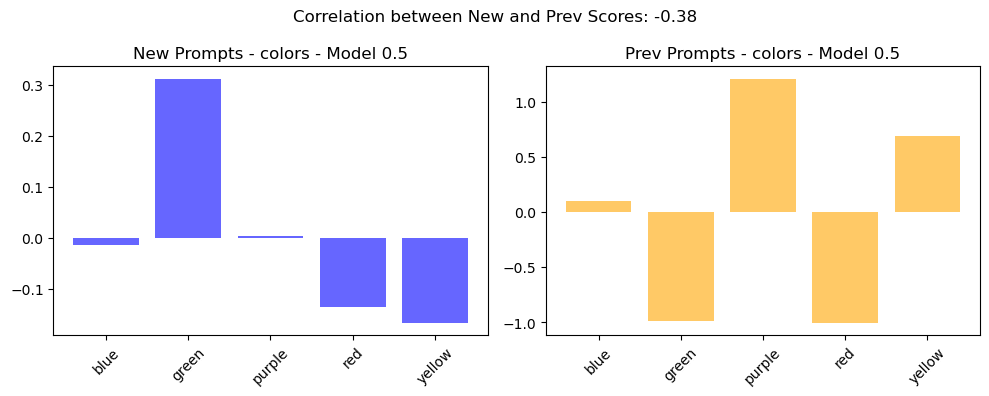

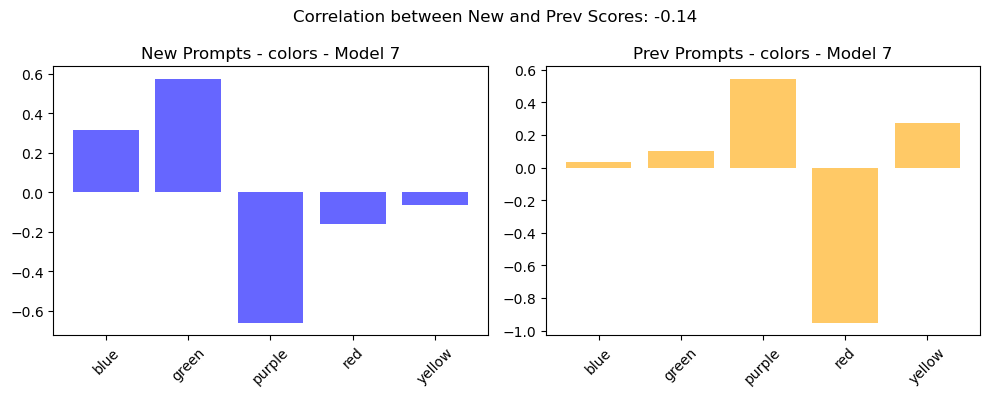

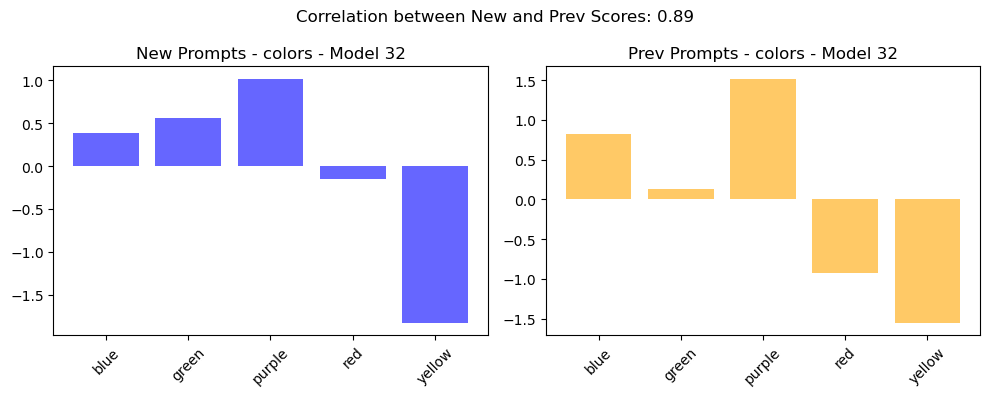

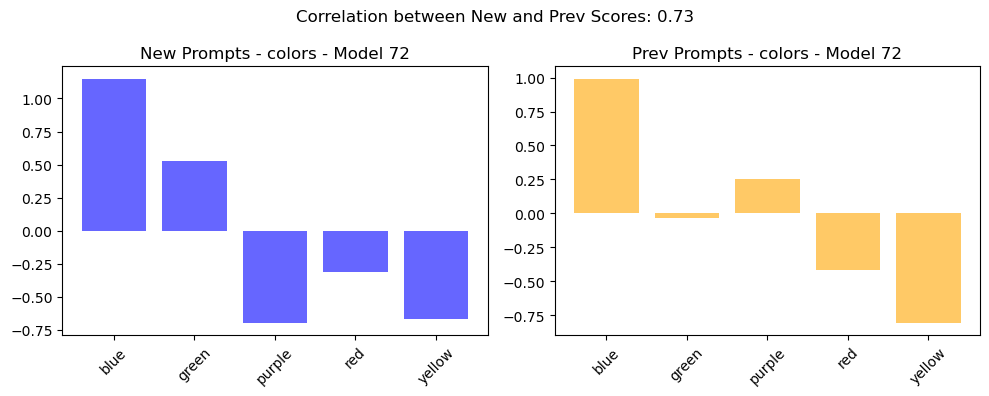

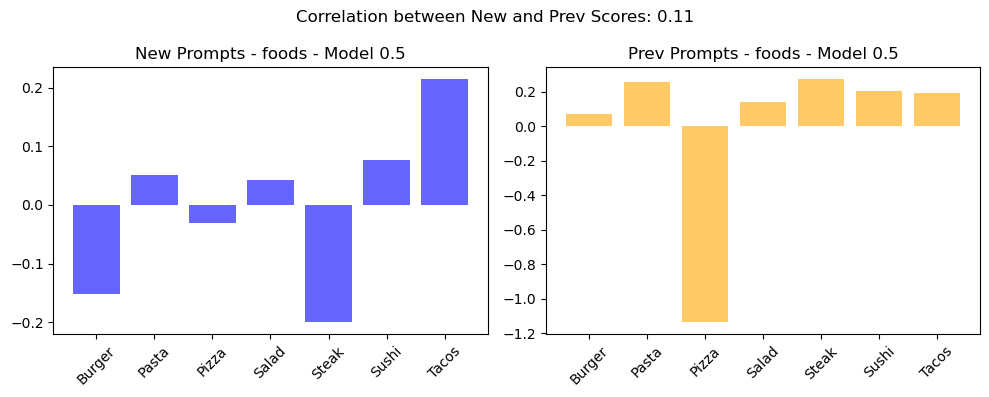

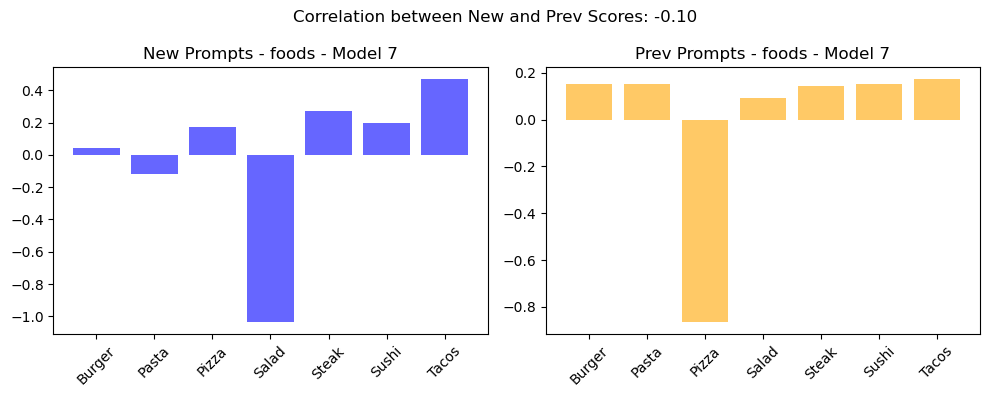

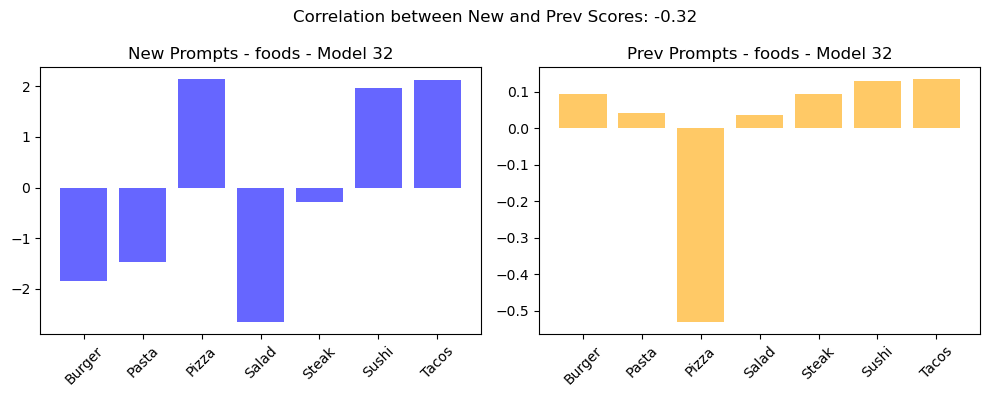

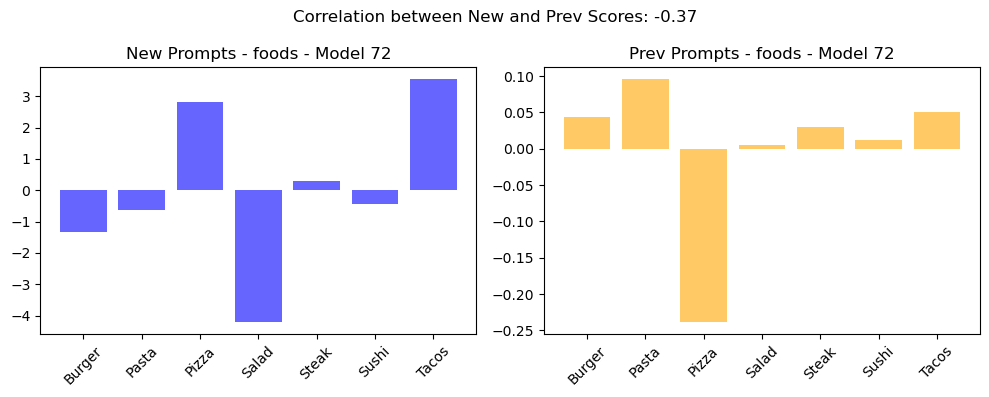

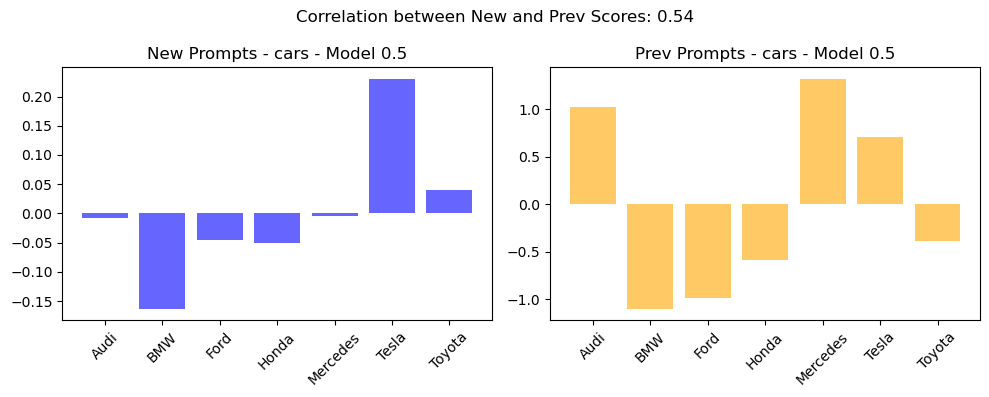

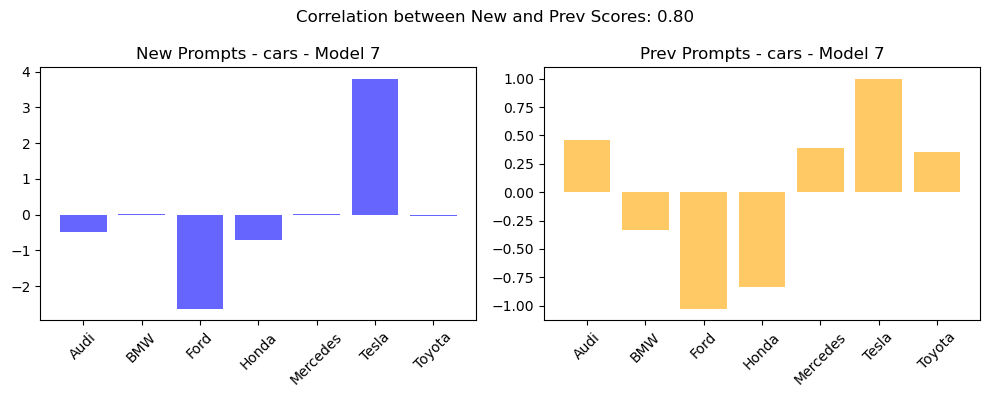

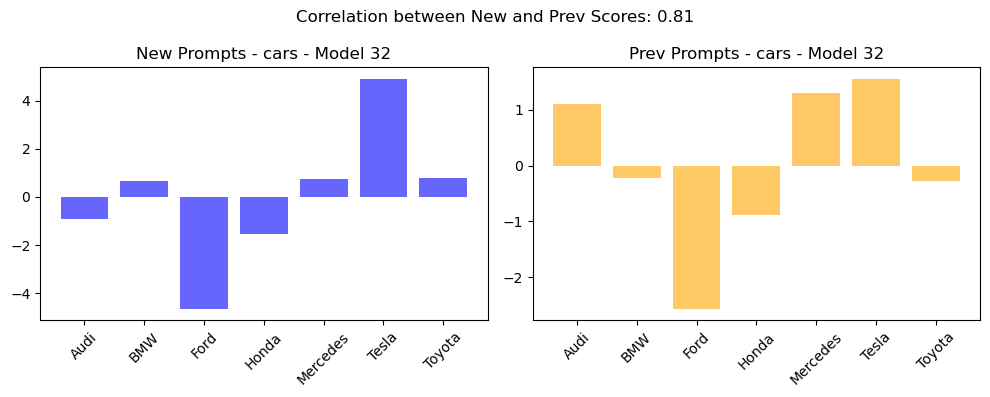

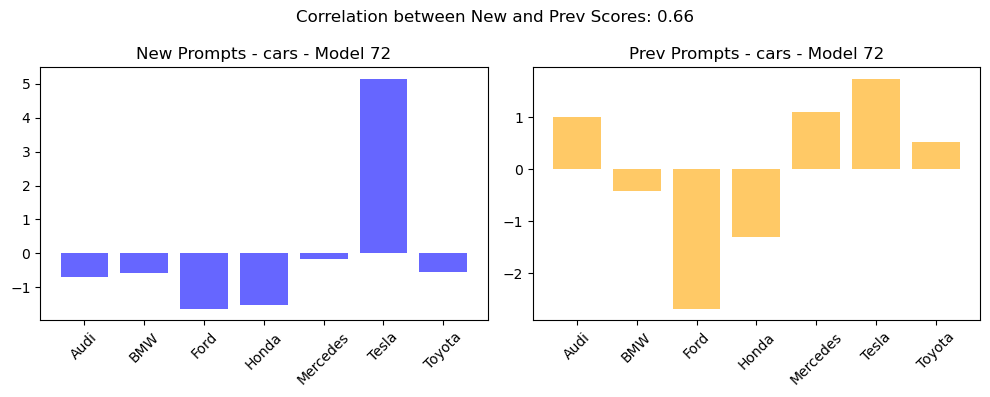

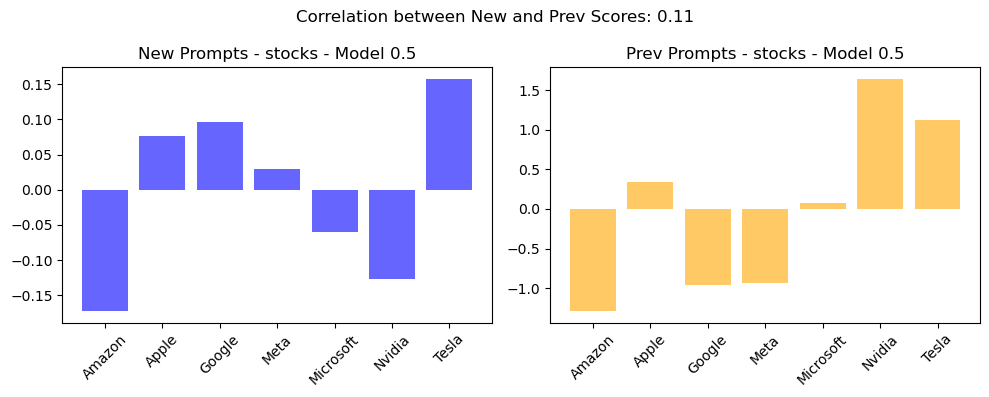

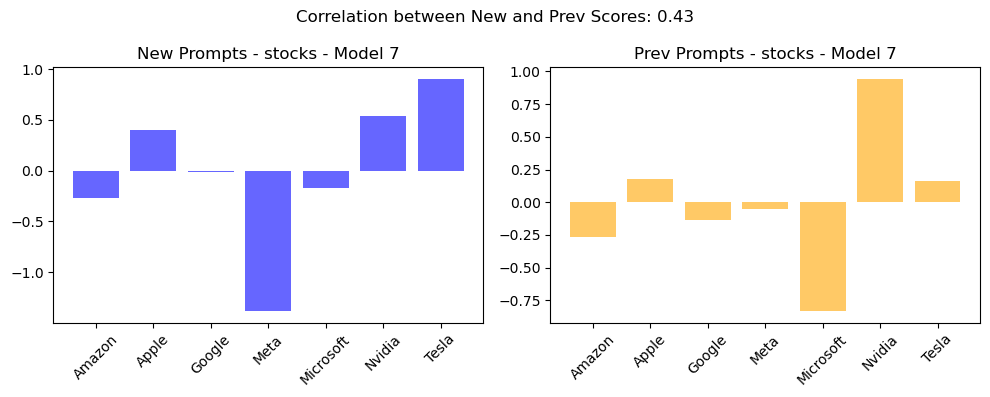

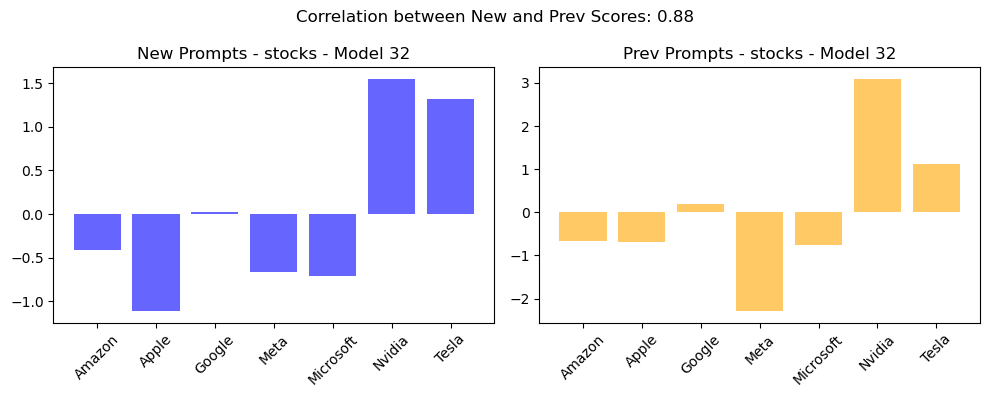

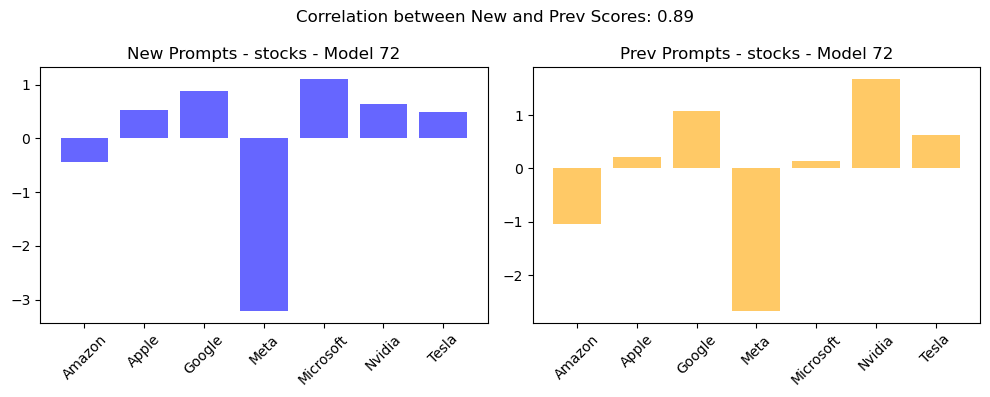

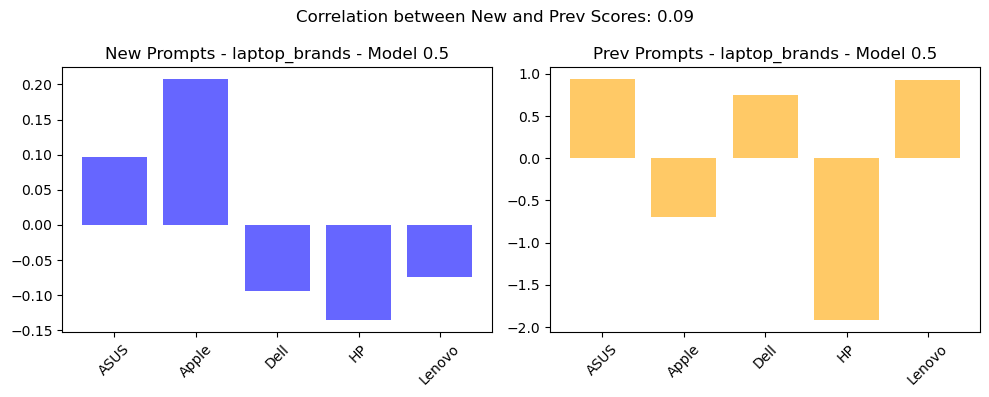

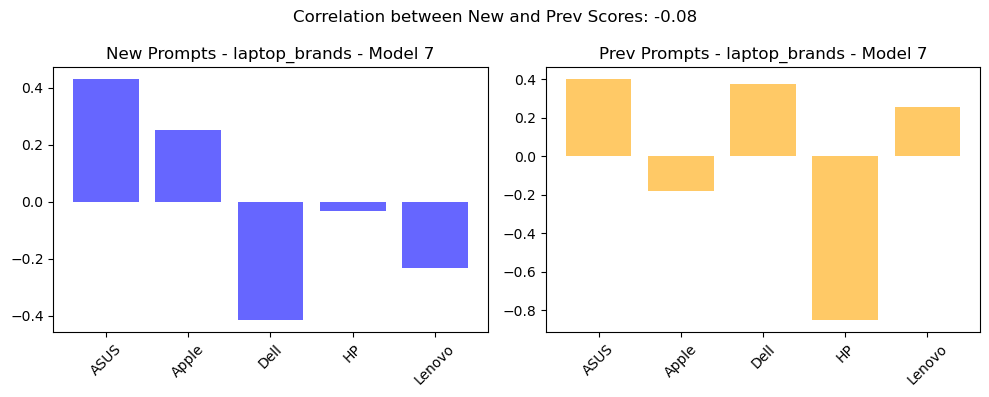

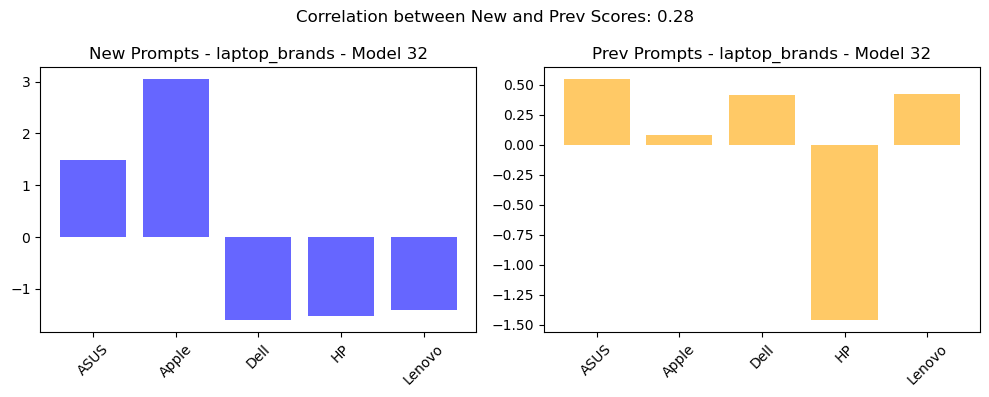

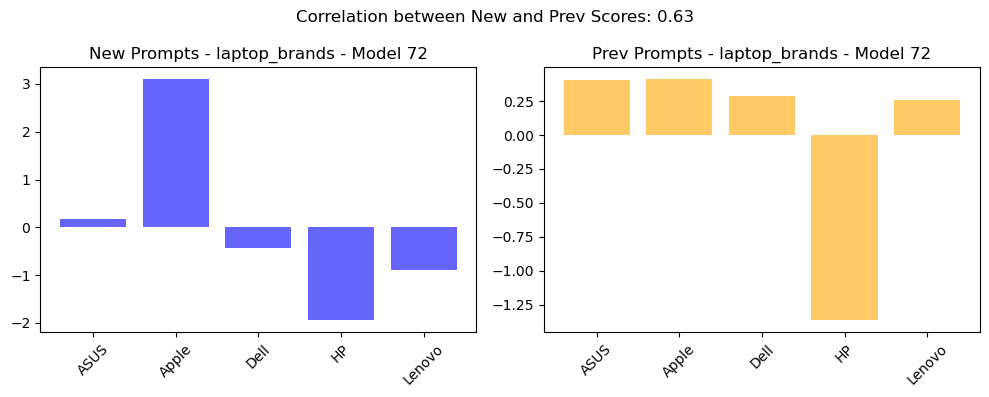

In [128]:
import matplotlib.pyplot as plt
for alt_set in ['colors', 'foods', 'cars', 'stocks', 'laptop_brands']:
    for model in ['0.5', '7', '32', '72']:
        set_map = mappings[alt_set]
        scores_new = records_new[alt_set][model]
        scores_prev = records_prev[alt_set][model]
        corr = np.corrcoef(scores_new, scores_prev)[0, 1]
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.bar(set_map.keys(), scores_new, color='blue', alpha=0.6)
        plt.title(f'New Prompts - {alt_set} - Model {model}')
        plt.xticks(rotation=45)
        plt.subplot(1, 2, 2)
        plt.bar(set_map.keys(), scores_prev, color='orange', alpha=0.6)
        plt.title(f'Prev Prompts - {alt_set} - Model {model}')
        plt.xticks(rotation=45)
        plt.suptitle(f'Correlation between New and Prev Scores: {corr:.2f}')
        plt.tight_layout()
        plt.show()
        

In [116]:
record = pd.DataFrame({
    'model_size': '72',
    'alternative_set': 'laptops',
    'rankings': None
}, index=[0])
prev_df = pd.concat([prev_df, record], ignore_index=True)
prev_df

,model_size,alternative_set,rankings
0,0.5,cars,Mercedes > Audi > Tesla > Toyota > Honda > For...
1,7,foods,Tacos > Pasta > Burger > Sushi > Steak > Salad...
2,32,foods,Tacos > Sushi > Burger > Steak > Pasta > Salad...
3,72,cars,Tesla > Mercedes > Audi > Toyota > BMW > Honda...
4,72,colors,blue > purple > green > red > yellow
5,0.5,laptop_brands,ASUS > Lenovo > Dell > Apple > HP
6,0.5,colors,purple > yellow > blue > green > red
7,0.5,laptops,"HP Pavilion 15 (Ryzen 5, 8GB, $600) > Apple Ma..."
8,0.5,foods,Steak > Pasta > Sushi > Tacos > Salad > Burger...
9,7,laptops,"ASUS VivoBook 15 (i3, 8GB, $450) > Lenovo Idea..."


In [118]:
df

,model_size,alternative_set,rankings
0,72,colors,blue > green > red > yellow > purple
1,0.5,foods,Tacos > Sushi > Pasta > Salad > Pizza > Burger...
2,32,laptops,"Lenovo ThinkPad X1 Carbon (Ryzen 7, 32GB, $140..."
3,7,stocks,Tesla > Nvidia > Apple > Google > Microsoft > ...
4,7,laptops,"Lenovo ThinkPad E14 (Ryzen 5, 16GB, $800) > Le..."
5,72,cars,Tesla > Mercedes > Toyota > BMW > Audi > Honda...
6,72,stocks,Microsoft > Google > Nvidia > Apple > Tesla > ...
7,32,stocks,Nvidia > Tesla > Google > Amazon > Meta > Micr...
8,0.5,cars,Tesla > Toyota > Mercedes > Audi > Ford > Hond...
9,7,laptop_brands,ASUS > Apple > HP > Lenovo > Dell


In [119]:
df.merge(prev_df, how='inner', on=['model_size', 'alternative_set'], suffixes=('_new', '_prev'))

,model_size,alternative_set,rankings_new,rankings_prev
0,72,colors,blue > green > red > yellow > purple,blue > purple > green > red > yellow
1,0.5,foods,Tacos > Sushi > Pasta > Salad > Pizza > Burger...,Steak > Pasta > Sushi > Tacos > Salad > Burger...
2,32,laptops,"Lenovo ThinkPad X1 Carbon (Ryzen 7, 32GB, $140...","Dell XPS 15 (i7, 32GB, $1500) > HP Pavilion 15..."
3,7,stocks,Tesla > Nvidia > Apple > Google > Microsoft > ...,Nvidia > Apple > Tesla > Meta > Google > Amazo...
4,7,laptops,"Lenovo ThinkPad E14 (Ryzen 5, 16GB, $800) > Le...","ASUS VivoBook 15 (i3, 8GB, $450) > Lenovo Idea..."
5,72,cars,Tesla > Mercedes > Toyota > BMW > Audi > Honda...,Tesla > Mercedes > Audi > Toyota > BMW > Honda...
6,72,stocks,Microsoft > Google > Nvidia > Apple > Tesla > ...,Nvidia > Google > Tesla > Apple > Microsoft > ...
7,32,stocks,Nvidia > Tesla > Google > Amazon > Meta > Micr...,Nvidia > Tesla > Google > Amazon > Apple > Mic...
8,0.5,cars,Tesla > Toyota > Mercedes > Audi > Ford > Hond...,Mercedes > Audi > Tesla > Toyota > Honda > For...
9,7,laptop_brands,ASUS > Apple > HP > Lenovo > Dell,ASUS > Dell > Lenovo > Apple > HP
